# 06 — Hypothesis H2: Input Size Impact

**Objective**  
Evaluate whether reducing input image size (e.g., 100×100 → 50×50) maintains model accuracy ≥ 97 %.

**Inputs**  
- Split manifests: `inputs/manifests/v1/{train,val,test}.csv`
- Images: `inputs/cherry_leaves_dataset/{healthy,powdery_mildew}`  
- Baseline model v1 reference (100×100)

**Outputs (planned)**  
- Trained model v2 (50×50 input)
- Comparative evaluation report under `artifacts/v2/reports/`
- Plots under `plots/v4/`

**Notes**  
The model architecture remains identical to v1.  
Only the input resolution changes, allowing direct accuracy comparison.

In [6]:
from pathlib import Path
import sys

def find_project_root(start: Path) -> Path:
    """Walk up until a folder containing 'src' is found, else return start."""
    p = start
    for _ in range(5):
        if (p / "src").exists():
            return p
        p = p.parent
    return start

PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.paths import PROJECT_ROOT, DATA_DIR, MANIFESTS_DIR, PLOTS_DIR, ARTIFACTS_DIR

print("PROJECT_ROOT:", PROJECT_ROOT)
print("DATA_DIR:", DATA_DIR)
print("MANIFESTS_DIR:", MANIFESTS_DIR)
print("PLOTS_DIR:", PLOTS_DIR)
print("ARTIFACTS_DIR:", ARTIFACTS_DIR)

PROJECT_ROOT: C:\Users\ksstr\Documents\Coding\milestone-project-5
DATA_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\inputs\cherry_leaves_dataset
MANIFESTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\inputs\manifests\v1
PLOTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v1
ARTIFACTS_DIR: C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts


### Experimental Context — Reusing the Baseline Setup

This notebook continues directly from **Notebook 05 (CNN v1)**.  
The same training, validation, and test manifests are reused to ensure  
a *controlled experiment* where the only modification is the **input image resolution**.

All preprocessing, batching, and label mapping steps remain identical  
to v1 for a one-to-one performance comparison.

In [7]:
# Modelling configuration (v2)
IMG_SIZE = (50, 50)   # reduced from (100, 100) in v1
BATCH_SIZE = 32
SEED = 42

print("Config v2 → IMG_SIZE:", IMG_SIZE, "| BATCH_SIZE:", BATCH_SIZE, "| SEED:", SEED)

import pandas as pd

paths = {
    "train": MANIFESTS_DIR / "train.csv",
    "val":   MANIFESTS_DIR / "val.csv",
    "test":  MANIFESTS_DIR / "test.csv",
}
for name, p in paths.items():
    assert p.exists(), f"Missing manifest: {p}"

df_train = pd.read_csv(paths["train"])
df_val   = pd.read_csv(paths["val"])
df_test  = pd.read_csv(paths["test"])

for name, df in [("train", df_train), ("val", df_val), ("test", df_test)]:
    print(f"{name:>5} n={len(df)}")
    vc = df["label"].value_counts(normalize=True).rename("proportion").round(3)
    print(vc, "\n")

Config v2 → IMG_SIZE: (50, 50) | BATCH_SIZE: 32 | SEED: 42
train n=2945
label
powdery_mildew    0.5
healthy           0.5
Name: proportion, dtype: float64 

  val n=631
label
healthy           0.501
powdery_mildew    0.499
Name: proportion, dtype: float64 

 test n=632
label
powdery_mildew    0.5
healthy           0.5
Name: proportion, dtype: float64 



### Dataset Pipeline (Reused from v1)

The same `tf.data` pipeline from CNN v1 is reused.  
Only `IMG_SIZE` is changed to `(50, 50)`.

In [8]:
import tensorflow as tf
import numpy as np

# Ensure reproducibility
SEED = 42
tf.random.set_seed(SEED)
np.random.seed(SEED)

AUTOTUNE = tf.data.AUTOTUNE

# Stable label map from train manifest (sorted → reproducible)
labels_sorted = sorted(df_train["label"].unique().tolist())
label_to_index = {lbl: i for i, lbl in enumerate(labels_sorted)}
index_to_label = {i: lbl for lbl, i in label_to_index.items()}
print("Label map (in-memory):", label_to_index)

def decode_and_resize(img_bytes, img_size=IMG_SIZE):
    """Decode JPEG/PNG, force 3 channels, resize, and return float32 in [0,1]."""
    img = tf.io.decode_image(img_bytes, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, img_size, method=tf.image.ResizeMethod.BILINEAR)
    img = tf.cast(img, tf.float32) / 255.0
    return img

def load_example(path, label, img_size=IMG_SIZE):
    """Read file, decode, resize, normalize; return (image, int_label)."""
    bytes_ = tf.io.read_file(path)
    img = decode_and_resize(bytes_, img_size)
    return img, label

def make_dataset(manifest_df, img_size=IMG_SIZE, batch_size=BATCH_SIZE, training=False, seed=SEED):
    """Build a performant tf.data pipeline from a manifest DataFrame."""
    paths = manifest_df["filepath"].astype(str).values
    labels = manifest_df["label"].map(label_to_index).astype("int32").values

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if training:
        ds = ds.shuffle(buffer_size=len(manifest_df), seed=seed, reshuffle_each_iteration=True)

    ds = ds.map(lambda p, y: load_example(p, y, img_size), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size, drop_remainder=training)
    ds = ds.prefetch(AUTOTUNE)
    return ds

# Build datasets (v2)
train_ds = make_dataset(df_train, training=True)
val_ds   = make_dataset(df_val, training=False)
test_ds  = make_dataset(df_test, training=False)

# Quick sanity check
xb, yb = next(iter(train_ds))
print("Batch →", xb.shape, yb.shape, "| range:", float(tf.reduce_min(xb)), "→", float(tf.reduce_max(xb)))

Label map (in-memory): {'healthy': 0, 'powdery_mildew': 1}
Batch → (32, 50, 50, 3) (32,) | range: 0.0 → 1.0


### Baseline CNN (v2) — Identical Architecture, Smaller Input

The model definition is **identical** to CNN v1 (Notebook 05).  
Only the input shape is adjusted to **(50, 50, 3)** to isolate the impact of resolution.

In [9]:
from tensorflow.keras import layers, models, callbacks
import matplotlib.pyplot as plt

# Output dirs for v2
MODEL_DIR = ARTIFACTS_DIR / "v2" / "models"
MODEL_DIR.mkdir(parents=True, exist_ok=True)

PLOTS_V3_DIR = PLOTS_DIR.parent / "v3"
PLOTS_V3_DIR.mkdir(parents=True, exist_ok=True)

def build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=2):
    """Simple baseline CNN: 2 conv blocks + dense head (same as v1)."""
    model = models.Sequential([
        layers.Input(shape=input_shape),

        layers.Conv2D(32, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Conv2D(64, (3, 3), activation="relu", padding="same"),
        layers.MaxPooling2D(2),

        layers.Flatten(),
        layers.Dense(128, activation="relu"),
        layers.Dropout(0.3),
        layers.Dense(num_classes, activation="softmax"),
    ])
    model.compile(
        optimizer="adam",
        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"]
    )
    return model

model_v2 = build_baseline_cnn(input_shape=(*IMG_SIZE, 3), num_classes=len(label_to_index))
model_v2.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_2 (Conv2D)               │ (None, 50, 50, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 25, 25, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 25, 25, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 12, 12, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 9216)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,179,776 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 2)              │           258 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,199,426 (4.58 MB)

 Trainable params: 1,199,426 (4.58 MB)

 Non-trainable params: 0 (0.00 B)

### Training Setup

Training configuration (epochs, callbacks, optimizer) remains **unchanged** from v1  
to maintain experimental consistency.

Epoch 1/20

Epoch 1: val_accuracy improved from None to 0.99208, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\models\cnn_v2_best.keras
92/92 - 2s - 17ms/step - accuracy: 0.9042 - loss: 0.2115 - val_accuracy: 0.9921 - val_loss: 0.0258
Epoch 2/20

Epoch 2: val_accuracy improved from 0.99208 to 0.99842, saving model to C:\Users\ksstr\Documents\Coding\milestone-project-5\artifacts\v2\models\cnn_v2_best.keras
92/92 - 1s - 9ms/step - accuracy: 0.9929 - loss: 0.0278 - val_accuracy: 0.9984 - val_loss: 0.0105
Epoch 3/20

Epoch 3: val_accuracy did not improve from 0.99842
92/92 - 1s - 9ms/step - accuracy: 0.9980 - loss: 0.0100 - val_accuracy: 0.9984 - val_loss: 0.0067
Epoch 4/20

Epoch 4: val_accuracy did not improve from 0.99842
92/92 - 1s - 8ms/step - accuracy: 1.0000 - loss: 0.0040 - val_accuracy: 0.9984 - val_loss: 0.0082
Epoch 5/20

Epoch 5: val_accuracy did not improve from 0.99842
92/92 - 1s - 9ms/step - accuracy: 0.9997 - loss: 0.0030 - val_accuracy: 0

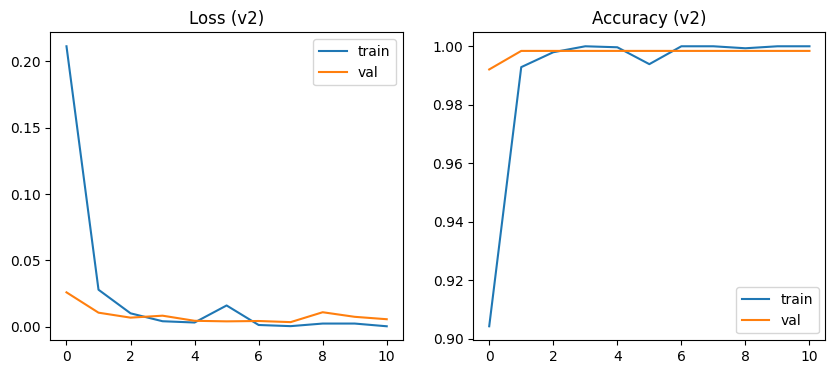

Saved: C:\Users\ksstr\Documents\Coding\milestone-project-5\plots\v3\training_curves_v2.png


In [10]:
EPOCHS = 20

cb_earlystop = callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,
    restore_best_weights=True
)
cb_checkpoint = callbacks.ModelCheckpoint(
    filepath=str(MODEL_DIR / "cnn_v2_best.keras"),
    monitor="val_accuracy",
    save_best_only=True,
    verbose=1
)

history_v2 = model_v2.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=[cb_earlystop, cb_checkpoint],
    verbose=2
)

# Curves
import pandas as pd
hist_df_v2 = pd.DataFrame(history_v2.history)
hist_path_v2 = MODEL_DIR / "cnn_v2_history.csv"
hist_df_v2.to_csv(hist_path_v2, index=False)
print("Saved training history:", hist_path_v2.resolve())

fig, ax = plt.subplots(1, 2, figsize=(10, 4))
ax[0].plot(history_v2.history["loss"], label="train")
ax[0].plot(history_v2.history["val_loss"], label="val")
ax[0].set_title("Loss (v2)")
ax[0].legend()

ax[1].plot(history_v2.history["accuracy"], label="train")
ax[1].plot(history_v2.history["val_accuracy"], label="val")
ax[1].set_title("Accuracy (v2)")
ax[1].legend()

out_plot_v2 = PLOTS_V3_DIR / "training_curves_v2.png"
fig.savefig(out_plot_v2, bbox_inches="tight", dpi=150)
plt.show()
plt.close(fig)
print("Saved:", out_plot_v2.resolve())